In [ ]:
import pandas as pd
import re
from IPython.display import display
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from google.colab import drive, runtime
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df_news = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news.shape

(199989, 5)

In [ ]:
# Snapshot of the original dataset for validation
try:
    df_raw = df_news.copy()
    print(f"df_raw snapshot created — shape: {df_raw.shape}")
    df_raw.head(3)
except NameError:
    print('df_news not defined yet — run the load cell first')

df_raw snapshot created — shape: (199989, 5)


In [4]:

print(df_news.isnull().sum())

url         0
date        0
language    0
title       0
text        0
dtype: int64


In [5]:
df_news.head(30)

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...
5,https://citylife.capetown/lb/uncategorized/how...,2023-12-12,en,Google Releases New Chatbot Bard as a Strong C...,Google Releases New Chatbot Bard as a Strong ...
6,https://citylife.capetown/technology/zoom-laun...,2023-09-07,en,Zoom Expands AI Offering with AI Companion and...,Zoom Expands AI Offering with AI Companion an...
7,https://citylife.capetown/uncategorized/pro-ai...,2023-08-04,en,Pro-AI Thinking: Enhancing Industrial Environm...,\n\nPro-AI Thinking: Enhancing Industrial Envi...
8,https://clickup.com/ai/prompts/business-risk-m...,2024-03-13,en,Best AI Prompts for Business Risk Management,Best AI Prompts for Business Risk ManagementPr...
9,https://crooksandliars.com/2025/12/state-ags-w...,2025-12-15,en,State AGs Warn AI Companies: Clean Up Your Chi...,\nState AGs Warn AI Companies: Clean Up Your C...


In [6]:
df_news["url"].head(30)

,url
0,https://blockworks.co/price/bad
1,https://boingboing.net/2024/07/01/this-ai-vide...
2,https://boingboing.net/2024/09/18/if-using-ai-...
3,https://citylife.capetown/gl/uncategorized/the...
4,https://citylife.capetown/kk/uncategorized/mic...
5,https://citylife.capetown/lb/uncategorized/how...
6,https://citylife.capetown/technology/zoom-laun...
7,https://citylife.capetown/uncategorized/pro-ai...
8,https://clickup.com/ai/prompts/business-risk-m...
9,https://crooksandliars.com/2025/12/state-ags-w...


In [7]:
print(df_news['text'][29])

Jukin Licensing Unveils Advanced AI Integration | LBBOnlineEDITION →Global  • USA  • UK  • AUNZ  • CANADA  • IRELAND  • FRANCE  • GERMANY  • ASIA  • EUROPE  • LATAM  • MEA Edition : InternationalLanguage : English HOMENEWSCREATIVE LIBRARYIMMORTAL AWARDSMEMBER COMPANIESPEOPLEJOBSHow LBB WorksPlans & PricingEditorial ToolkitnewsNEWSCREATIVE LIBRARYIMMORTAL AWARDSMEMBER COMPANIESPEOPLEJOBSLogin or RegisterHires, Wins & Business in association withLBB Reel BuilderHires, Wins & BusinessJukin Licensing Unveils Advanced AI Integration27/08/2025lbbonline.com 1LIKEADD TO COLLECTION27/08/2025ShareTechnology integration reinvents access to the world’s largest user-generated content library​Jukin Licensing, the recognised leader in authentic, commercially cleared user-generated content (UGC), is announcing a major leap forward in UGC technology integration. The company’s new AI integration enables advertisers, their agencies, media and storytellers to unlock the full potential of Jukin’s expansive

In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove non-ASCII characters
    text = text.encode('ascii', 'ignore').decode()
    # Replace multiple spaces, newlines, and tabs with a single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning function.
df_news['cleaned_text'] = df_news['text'].apply(clean_text)

# Drop rows where the cleaned text is empty
df_news = df_news[df_news['cleaned_text'] != ""]
print(f"Shape after cleaning: {df_news.shape}")

Shape after cleaning: (199989, 6)


In [9]:
# Define our domain keywords and combine them
ai_keywords = [
    r'\bartificial intelligence\b',
    r'\bai\b',
    r'\bmachine learning\b',
    r'\bdeep learning\b',
    r'\bgenerative ai\b',
    r'\bllm\b',
    r'\bchatgpt\b',
    r'\bautomation\b',
    r'\bnlp\b',
    r'\bopenai\b',
    r'\bopenclaw\b',
    r'\banthropic\b',
    r'\bclaude\b',

]

In [ ]:
# --- Validation: initial cleaning ---

pattern = '|'.join(ai_keywords)

print('Validation: after initial cleaning')
try:
    print(f"- original (df_raw) shape: {df_raw.shape}")
except NameError:
    print('- df_raw not available (run the snapshot cell)')

print(f"- after cleaning (df_news) shape: {df_news.shape}")

# identify removed rows relative to original snapshot (if available)
try:
    removed_idx = df_raw.index.difference(df_news.index)
    removed_df = df_raw.loc[removed_idx] if len(removed_idx) > 0 else df_raw.iloc[0:0]
    print(f"- removed count: {removed_df.shape[0]}")
    if removed_df.shape[0] > 0:
        mask_raw = removed_df['text'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
        mask_clean = removed_df.get('cleaned_text', removed_df['text']).astype(str).str.contains(pattern, case=False, na=False, regex=True)
        print(f"- removed with AI keywords in raw text: {mask_raw.sum()}")
        print(f"- removed with AI keywords in cleaned_text: {mask_clean.sum()}")
        if mask_raw.sum() > 0:
            print('\nSample removed rows that mention AI (raw text):')
            display(removed_df[mask_raw][['url','text']].head(5))
        else:
            print('No removed rows contained AI keywords.')
except Exception as e:
    print('Validation step failed:', e)

Validation: after initial cleaning
- original (df_raw) shape: (199989, 5)
- after cleaning (df_news) shape: (199989, 6)
- removed count: 0


In [11]:
# Filter rows where 'cleaned_text' contains any keywords
df_filtered = df_news[df_news['cleaned_text'].str.contains(pattern, case=False, na=False, regex=True)].copy()

print(f"Shape after filtering for AI keywords: {df_filtered.shape}")
print(f"Discarded irrelevant articles count: {df_news.shape[0] - df_filtered.shape[0]} ")


Shape after filtering for AI keywords: (196256, 6)
Discarded irrelevant articles count: 3733 


In [12]:
# --- Validation: initial AI-keyword filtering ---
print('Validation: after AI keyword filtering (initial)')
print(f"- input shape (df_news): {df_news.shape}")
print(f"- filtered shape (df_filtered): {df_filtered.shape}")

discarded_idx = df_news.index.difference(df_filtered.index)
discarded_df = df_news.loc[discarded_idx] if len(discarded_idx) > 0 else df_news.iloc[0:0]
print(f"- discarded count: {discarded_df.shape[0]}")
if discarded_df.shape[0] > 0:
    mask = discarded_df['cleaned_text'].astype(str).str.contains(pattern, case=False, na=False, regex=True) | discarded_df['text'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
    print(f"- discarded but matching AI keywords (raw or cleaned): {mask.sum()}")
    if mask.sum() > 0:
        print('\nSample discarded rows that match AI keywords:')
        display(discarded_df[mask][['url','text']].head(5))
else:
    print('No rows discarded by this filter.')

Validation: after AI keyword filtering (initial)
- input shape (df_news): (199989, 6)
- filtered shape (df_filtered): (196256, 6)
- discarded count: 3733
- discarded but matching AI keywords (raw or cleaned): 14

Sample discarded rows that match AI keywords:


,url,text
5258,https://www.politico.com/minutes/congress/06-2...,Ted Lieu warned lawmakers of the pitfalls of r...
18873,https://www.latestly.com/technology/layoffs-co...,\n\nLayoffs Continue Under Mark Zuckerberg: Me...
30957,https://www.levels.fyi/t/data-scientist/locati...,"Data Scientist Salary in Delhi, IndiaFor Emplo..."
34763,https://www.cnn.com/2023/11/22/tech/openai-sam...,\nOpenAI’s wild week explained: How the Sam Al...
39535,https://instapundit.com/574441/,\n\nInstapundit » Blog Archive » THE SINGUL...


In [13]:
df_filtered.head()

,url,date,language,title,text,cleaned_text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,This AI video of gymnastics might be the freak...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...","If using AI feels like a chore, try this - Boi..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,The Road Ahead: How China's AI Foundation Mode...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,Microsoft and Nvidia to Empower Developers wit...


# Enhanced Exploratory Data Analysis

In this section, we will perform a detailed exploratory data analysis (EDA) to better understand the dataset and extract meaningful insights for the NLP task. The goal is to identify industries and companies impacted by AI, understand the nature of the impact, and gather insights on AI adoption.

In [14]:
# Analyze the distribution of article lengths
article_lengths = df_news['cleaned_text'].str.len()
article_lengths.describe()

,cleaned_text
count,199989.000000
mean,8343.710149
std,6370.483871
min,20.000000
25%,4905.000000
50%,7109.000000
75%,10385.000000
max,402693.000000


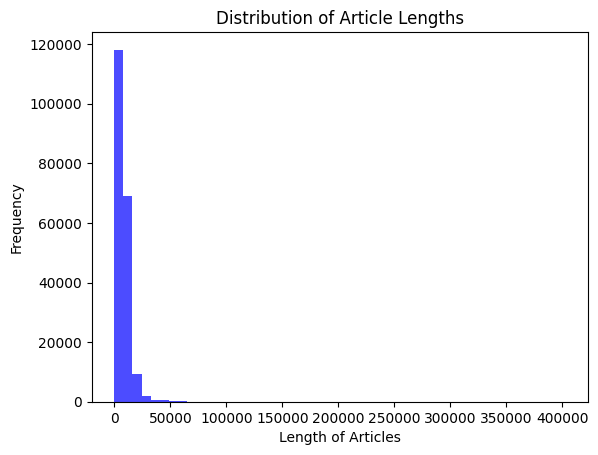

In [ ]:
# Visualize the distribution of article lengths

plt.hist(article_lengths, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Article Lengths')
plt.xlabel('Length of Articles')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Analyze the frequency of AI-related keywords

keyword_counts = Counter()
for text in df_filtered['cleaned_text']:
    for keyword in ai_keywords:
        if re.search(keyword, text, re.IGNORECASE):
            keyword_counts[keyword] += 1

print("Keyword Frequency:")
for keyword, count in keyword_counts.items():
    print(f"{keyword}: {count}")

Keyword Frequency:
\bai\b: 189591
\bchatgpt\b: 52637
\banthropic\b: 7387
\bclaude\b: 5637
\bartificial intelligence\b: 122111
\bdeep learning\b: 7197
\bllm\b: 8220
\bopenai\b: 44299
\bgenerative ai\b: 43754
\bautomation\b: 25159
\bmachine learning\b: 30053
\bnlp\b: 3975
\bopenclaw\b: 68


/tmp/ipykernel_5191/2900317514.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(keywords), palette='viridis')


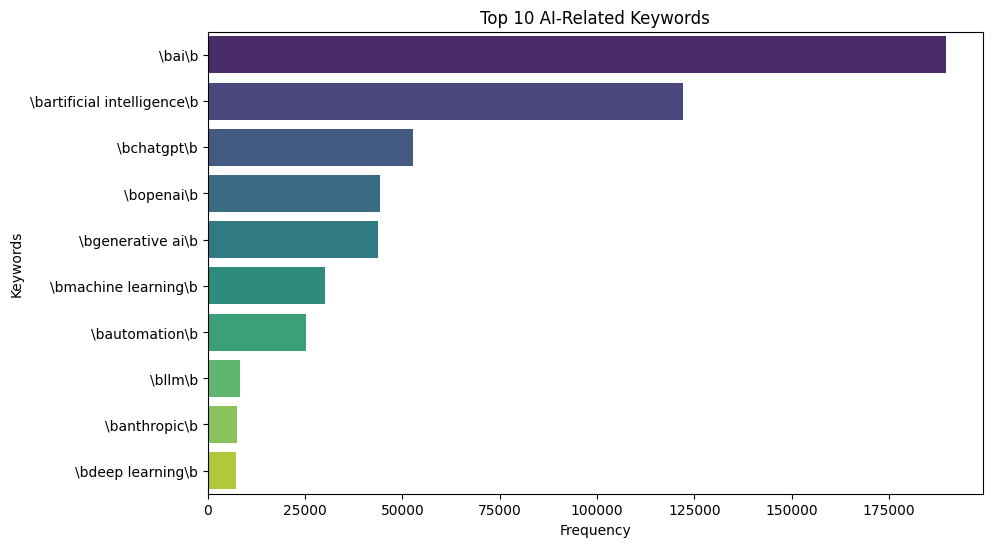

In [ ]:
# Visualize the top AI-related keywords


keywords, counts = zip(*keyword_counts.most_common(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(keywords), palette='viridis')
plt.title('Top 10 AI-Related Keywords')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.show()

## Cleaning Pipeline

This pipeline improves text cleaning, detects language, removes and short/noisy articles, and re-filters for AI-related content. The cleaned dataset will be written to `news_cleaned_filtered_v2.parquet` for downstream analysis (NER, topic modeling, impact classification).

In [ ]:
!pip install -q langdetect beautifulsoup4

from bs4 import BeautifulSoup
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
import html, hashlib

print('Cleaning libs ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Cleaning libs ready


In [ ]:
def clean_text_v2(text):
    if not isinstance(text, str) or not text:
        return ''

    # Unescape HTML entities (lightweight)
    try:
        text = html.unescape(text)
    except Exception:
        pass

    # Remove script/style blocks (non-greedy with DOTALL/IGNORECASE)
    text = re.sub(r'(?is)<script[^>]*>.*?</script>', ' ', text)
    text = re.sub(r'(?is)<style[^>]*>.*?</style>', ' ', text)

    # Remove all remaining HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs and emails
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove common boilerplate phrases (case-insensitive)
    boilerplate = r'(read more|subscribe|sign up|follow us|continue reading|copyright\s*\d{4}|click here|advertis(e|ing)|powered by|learn more)'
    text = re.sub(boilerplate, ' ', text, flags=re.I)

    # Normalize whitespace and strip
    text = re.sub(r'\s+', ' ', text).strip()

    # Drop control/non-printable characters
    text = ''.join(ch for ch in text if ord(ch) >= 32)

    return text



In [21]:
try:
    df_pre_v2 = df_news.copy()
    print('Snapshot df_pre_v2 shape =', df_pre_v2.shape)
except NameError:
    print('df_news not defined — run previous cells first')


def amputate_boilerplate(text):
    if not isinstance(text, str):
        return ("", False, False)

    t = html.unescape(text).strip()

    dateline_patterns = [
        # Wire services with various separators
        r'^.*?(?:PRNewswire|PR Newswire|Reuters|Business Wire|GlobeNewswire|Accesswire|Gray Television|Gray Media|Gray Media Group).*?(?:--|—|- )',
        # Press release headers
        r'^.*?\b(?:PRESS RELEASE|NEWS PROVIDED BY)\b.*?(?:--|—|- )',
        # Dateline format: CITY, State, Date /PRNewswire--
        r'^\w+,\s+\w+\s+\d{1,2},?\s+\d{4}\s+/PRNewswire.*?--',
        # Generic wire service datelines
        r'^.*?(?:via|from|source:)\s+(?:PRNewswire|Reuters|Business Wire|GlobeNewswire).*?(?:--|—)',
        # Image link noise (FIXED syntax error here)
        r'^.*?(?:Getty|Getty Images|\.jpg|\.jpeg|\.png).*?(?:--|—|- )',
    ]

    removed_dateline = False

    for pattern in dateline_patterns:
        t_new, count = re.subn(pattern, '', t, count=1, flags=re.I | re.S)

        if count > 0:
            t = t_new  # Update 't' with the cleaned text
            removed_dateline = True
            break      # Stop checking other patterns

    footer_phrases = [
        r'to view the original version',
        r'view original content',
        r'original content to download',
        r'about gray television',
        r'about gray media',
        r'gray television',
        r'gray media group',
        r'view original content',
        r'original content to download multimedia',
        r'copyright \d{4}',
        r'copyright',
        r'all rights reserved',
        r'click here to subscribe',
        r'learn more at',
        r'source \w+',
        r'media contact:',
        r'investor relations:',
        r'view source version on',
        r'businesswire\.com',
        r'prnewswire\.com',
        r'globenewswire\.com',
        r'accesswire\.com',
        r'for more information',
        r'visit our website',
        r'contact information',
        r'subscribe'
    ]
    footer_pattern = '|'.join(footer_phrases)
    footer_regex = re.compile(footer_pattern, re.I)
    parts = footer_regex.split(t)
    removed_footer = len(parts) > 1
    if removed_footer:
        t = parts[0]

    return (t.strip(), removed_dateline, removed_footer)

df_news[['amp_text','amp_dateline_removed','amp_footer_removed']] = df_news['text'].apply(lambda x: pd.Series(amputate_boilerplate(x)))
print('Applied amputate_boilerplate — datelines removed:', df_news['amp_dateline_removed'].sum(), ' footers removed:', df_news['amp_footer_removed'].sum())


Snapshot df_pre_v2 shape = (199989, 6)
Applied amputate_boilerplate — datelines removed: 62807  footers removed: 166166


In [22]:
df_news.to_parquet('news_ampt_text.parquet', engine='pyarrow')


### Title Alignment: Remove Everything Before Article Title

This step aligns the text by removing everything that appears before the actual article title. By doing this early (before `clean_text_v2`), we reduce the amount of text to process in subsequent steps.

In [ ]:
# --- Title-alignment: remove everything before the article title (chunked) ---


# tries exact, normalized, and prefix matches
def extract_from_title_pair(text, title):
    if not isinstance(text, str) or not isinstance(title, str) or not title.strip():
        return text, False
    try:
        # 1) Exact regex-escaped match
        title_esc = re.escape(title.strip())
        m = re.search(title_esc, text, flags=re.I | re.S)
        if m:
            return text[m.start():].strip(), True

        # 2) Normalized match: remove punctuation and collapse whitespace
        def normalize(s):
            s2 = re.sub(r'[^\w\s]', ' ', s)
            s2 = re.sub(r'\s+', ' ', s2).strip().lower()
            return s2

        ntitle = normalize(title)
        ntext = normalize(text)
        if ntitle and ntitle in ntext:
            token = ntitle.split()[0]
            idx = re.search(re.escape(token), text, flags=re.I)
            if idx:
                return text[idx.start():].strip(), True

        # 3) Prefix heuristic: look for first 30 chars of title
        prefix = title.strip()[:30]
        if prefix:
            idx = text.lower().find(prefix.lower())
            if idx != -1:
                return text[idx:].strip(), True

    except Exception:
        pass
    return text, False

# Initialize columns with proper index alignment
df_news['text_after_title'] = df_news['amp_text'] 
df_news['title_found'] = False

chunk_size = 5000
n = len(df_news)
print(f"Aligning {n:,} articles to start from title...")

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)
    idx = df_news.index[start:end]

    for i in idx:
        text = df_news.loc[i, 'amp_text']
        title = df_news.loc[i, 'title']
        aligned_text, found = extract_from_title_pair(text, title)

        df_news.loc[i, 'text_after_title'] = aligned_text
        df_news.loc[i, 'title_found'] = found

    print(f'  Processed rows {start:,}..{end-1:,}')

# Reporting
titles_found = df_news['title_found'].sum()
titles_not_found = (~df_news['title_found']).sum()
print(f"\nTitle alignment complete:")
print(f"  Found: {titles_found:,} / {len(df_news):,} ({titles_found/len(df_news)*100:.1f}%)")
print(f"  Not found: {titles_not_found:,}")

# VALIDATION: Verify alignment by checking a few samples
print("\n VALIDATION: Checking alignment integrity...")
sample_indices = df_news.sample(min(5, len(df_news)), random_state=42).index
alignment_verified = True
for i in sample_indices:
    original = df_news.loc[i, 'amp_text']
    aligned = df_news.loc[i, 'text_after_title']
    title = df_news.loc[i, 'title']

    if aligned not in original:
        print(f"ALIGNMENT ERROR at index {i}")
        alignment_verified = False
    elif df_news.loc[i, 'title_found'] and title and title.strip()[:20].lower() not in aligned[:200].lower():
        print(f"POTENTIAL ISSUE at index {i}: title not found in aligned text")
        alignment_verified = False

if alignment_verified:
    print("Alignment verified - sample checks passed")
else:
    print("Alignment issues detected - review the results")

if titles_not_found > 0 and titles_not_found <= 20:
    print('\n Sample where title NOT found:')
    display(df_news[~df_news['title_found']][['url','title','amp_text']].head(10))

df_news.loc[df_news['title_found'], 'amp_text'] = df_news.loc[df_news['title_found'], 'text_after_title']
print(f'\n Updated amp_text for {titles_found:,} articles (where title was found)')
print(f"  These aligned texts will now be processed by clean_text_v2")

# Clean up temporary column to save memory
df_news.drop(columns=['text_after_title'], inplace=True)
print(" Temporary columns cleaned up")

Aligning 199,989 articles to start from title...
  Processed rows 0..4,999
  Processed rows 5,000..9,999
  Processed rows 10,000..14,999
  Processed rows 15,000..19,999
  Processed rows 20,000..24,999
  Processed rows 25,000..29,999
  Processed rows 30,000..34,999
  Processed rows 35,000..39,999
  Processed rows 40,000..44,999
  Processed rows 45,000..49,999
  Processed rows 50,000..54,999
  Processed rows 55,000..59,999
  Processed rows 60,000..64,999
  Processed rows 65,000..69,999
  Processed rows 70,000..74,999
  Processed rows 75,000..79,999
  Processed rows 80,000..84,999
  Processed rows 85,000..89,999
  Processed rows 90,000..94,999
  Processed rows 95,000..99,999
  Processed rows 100,000..104,999
  Processed rows 105,000..109,999
  Processed rows 110,000..114,999
  Processed rows 115,000..119,999
  Processed rows 120,000..124,999
  Processed rows 125,000..129,999
  Processed rows 130,000..134,999
  Processed rows 135,000..139,999
  Processed rows 140,000..144,999
  Processed r

In [ ]:
def apply_clean_in_chunks(df, src_col='amp_text', dst_col='cleaned_text_v2', func=clean_text_v2, chunk_size=5000, start_index=0):
    n = len(df)
    if start_index == 0:
        df[dst_col] = None
    else:
        print("Seems like there is v2 cleand data")
        print(df[dst_col].count())
    for start in range(start_index, n, chunk_size):
        end = min(start + chunk_size, n)
        idx = df.index[start:end]
        df.loc[idx, dst_col] = df.loc[idx, src_col].apply(func)
        print(f'Processed rows {start}..{end-1}')
    return df
    
df_news = apply_clean_in_chunks(df_news, chunk_size=5000, start_index=0)
print('Applied clean_text_v2 — non-empty count:', (df_news['cleaned_text_v2'] != '').sum())




Processed rows 0..4999
Processed rows 5000..9999
Processed rows 10000..14999
Processed rows 15000..19999
Processed rows 20000..24999
Processed rows 25000..29999
Processed rows 30000..34999
Processed rows 35000..39999
Processed rows 40000..44999
Processed rows 45000..49999
Processed rows 50000..54999
Processed rows 55000..59999
Processed rows 60000..64999
Processed rows 65000..69999
Processed rows 70000..74999
Processed rows 75000..79999
Processed rows 80000..84999
Processed rows 85000..89999
Processed rows 90000..94999
Processed rows 95000..99999
Processed rows 100000..104999
Processed rows 105000..109999
Processed rows 110000..114999
Processed rows 115000..119999
Processed rows 120000..124999
Processed rows 125000..129999
Processed rows 130000..134999
Processed rows 135000..139999
Processed rows 140000..144999
Processed rows 145000..149999
Processed rows 150000..154999
Processed rows 155000..159999
Processed rows 160000..164999
Processed rows 165000..169999
Processed rows 170000..1749

In [ ]:
# Language detection and basic deduplication

def detect_lang_safe(text):
    try:
        if len(text.split()) < 10:
            return 'short'
        return detect(text)
    except:
        return 'unknown'

# Add language column
df_news['lang'] = df_news['cleaned_text_v2'].apply(detect_lang_safe)
print('Language distribution (top):')
print(df_news['lang'].value_counts().head())

# Keep only English articles
before = df_news.shape[0]
df_news = df_news[df_news['lang'] == 'en'].copy()
print(f'Kept {df_news.shape[0]} English articles (dropped {before - df_news.shape[0]})')

# Remove exact duplicate texts via MD5 hash
df_news['text_hash'] = df_news['cleaned_text_v2'].apply(lambda x: hashlib.md5(x.encode('utf-8')).hexdigest())
before = df_news.shape[0]
df_news = df_news.drop_duplicates(subset='text_hash')
print('Removed exact duplicates, remaining:', df_news.shape[0])

# Remove very short articles (noise)
before = df_news.shape[0]
df_news = df_news[df_news['cleaned_text_v2'].str.len() >= 300].copy()
print('Removed short articles (<300 chars), remaining:', df_news.shape[0])

Language distribution (top):
lang
en       194731
short      4347
de          429
it           96
id           83
Name: count, dtype: int64
Kept 194731 English articles (dropped 5258)
Removed exact duplicates, remaining: 169338
Removed short articles (<300 chars), remaining: 148983


In [26]:
# --- Validation: v2 cleaning + language detection + dedup ---
print('Validation: after v2 cleaning + language/dedup')
try:
    print(f"- before (df_pre_v2) shape: {df_pre_v2.shape}")
except NameError:
    print('- df_pre_v2 snapshot not found')

print(f"- after (df_news) shape: {df_news.shape}")
try:
    removed_idx = df_pre_v2.index.difference(df_news.index)
    removed_df = df_pre_v2.loc[removed_idx] if len(removed_idx) > 0 else df_pre_v2.iloc[0:0]
    print(f"- removed count: {removed_df.shape[0]}")
    if removed_df.shape[0] > 0:
        mask_raw = removed_df['text'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
        mask_v2 = removed_df.get('cleaned_text_v2', removed_df['text']).astype(str).str.contains(pattern, case=False, na=False, regex=True)
        print(f"- removed with AI keywords in raw text: {mask_raw.sum()}")
        print(f"- removed with AI keywords in cleaned_text_v2: {mask_v2.sum()}")
        if mask_raw.sum() > 0:
            print('\nSample removed rows that mention AI (raw text):')
            display(removed_df[mask_raw][['url','text']].head(5))
    else:
        print('No rows removed at this step.')
except Exception as e:
    print('Validation step failed:', e)

Validation: after v2 cleaning + language/dedup
- before (df_pre_v2) shape: (199989, 6)
- after (df_news) shape: (148983, 13)
- removed count: 51006
- removed with AI keywords in raw text: 50066
- removed with AI keywords in cleaned_text_v2: 50066

Sample removed rows that mention AI (raw text):


,url,text
12,https://economictimes.indiatimes.com/magazines...,IIM Ahmedabad student writes project using Cha...
20,https://gizmodo.com.au/2023/07/hasbro-may-be-e...,\n\nHasbro May Be Eyeing AI for Dungeons & Dra...
21,https://gizmodo.com/meta-releases-seamlessm4t-...,Meta Releases SeamlessM4T Translation AI for T...
22,https://hackernoon.com/smart-fire-protection-h...,Smart Fire Protection: How AI Is Changing Prev...
24,https://itbusinessnet.com/2025/07/imagen-netwo...,\n\nImagen Network (IMAGE) to Integrate Advanc...


In [ ]:
# Re-filter for AI keywords using cleaned text and save the cleaned parquet
before = df_news.shape[0]
df_news_filtered_v2 = df_news[df_news['cleaned_text_v2'].str.contains(pattern, case=False, na=False, regex=True)].copy()
after = df_news_filtered_v2.shape[0]
print(f'Filtered from {before} -> {after} AI-relevant articles')

Filtered from 148983 -> 142007 AI-relevant articles


In [29]:
# --- Validation: final AI filtering (v2) ---
print('Validation: final AI filtering (v2)')
print(f"- before filter (df_news) shape: {df_news.shape}")
print(f"- after filter (df_news_filtered_v2) shape: {df_news_filtered_v2.shape}")

removed_idx = df_news.index.difference(df_news_filtered_v2.index)
removed_df = df_news.loc[removed_idx] if len(removed_idx) > 0 else df_news.iloc[0:0]
print(f"- removed count: {removed_df.shape[0]}")
if removed_df.shape[0] > 0:
    mask_orig = removed_df['text'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
    mask_clean_v2 = removed_df['cleaned_text_v2'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
    print(f"- removed rows where original text contained AI keywords: {mask_orig.sum()}")
    print(f"- removed rows where cleaned_text_v2 contained AI keywords: {mask_clean_v2.sum()}")
    diff_mask = mask_orig & (~mask_clean_v2)
    print(f"- rows where original had AI keyword but cleaned_v2 did not: {diff_mask.sum()}")
    if diff_mask.sum() > 0:
        print('\nSample removed rows where original contained AI keywords but cleaned_text_v2 did not:')
        display(removed_df[diff_mask][['url','text','cleaned_text_v2']].head(5))
else:
    print('No rows removed by final filter.')

# Summary of stage sizes (quick overview)
print('\nQuick stage summary:')
try:
    print('raw (df_raw):', df_raw.shape)
except:
    print('raw (df_raw): not available')
try:
    print('initial filtered (df_filtered):', df_filtered.shape)
except:
    print('initial filtered (df_filtered): not available')
try:
    print('before v2 (df_pre_v2):', df_pre_v2.shape)
except:
    print('before v2 (df_pre_v2): not available')
print('after v2 + dedup (df_news):', df_news.shape)
print('final filtered (df_news_filtered_v2):', df_news_filtered_v2.shape)

Validation: final AI filtering (v2)
- before filter (df_news) shape: (148983, 13)
- after filter (df_news_filtered_v2) shape: (142007, 13)
- removed count: 6976
- removed rows where original text contained AI keywords: 4194
- removed rows where cleaned_text_v2 contained AI keywords: 0
- rows where original had AI keyword but cleaned_v2 did not: 4194

Sample removed rows where original contained AI keywords but cleaned_text_v2 did not:


,url,text,cleaned_text_v2
17,https://finance.yahoo.com/news/chegg-rallies-s...,Edtech Chegg rallies as strong quarter eases f...,and says stocks are overvalued and set to plun...
38,https://radaronline.com/p/tiger-king-joe-exoti...,Tiger King's Joe Exotic Releases Artificial In...,as He Battles Scabies!DAILY. BREAKING. CELEBRI...
89,https://www.finanznachrichten.de/nachrichten-2...,Rescale Inc: Slurm-Rescale Connector Brings Fu...,"Rescale, the leader in high performance comput..."
140,https://www.nasdaq.com/articles/new-browser-wa...,\nThe New Browser Wars: Alphabet's Distributio...,"more than anything, Google is in the content d..."
246,https://singularityhub.com/2024/07/19/openais-...,\n\n\nOpenAI’s Project Strawberry Said to Be B...,"and for How Long July 18, 2024 Could We Turn M..."



Quick stage summary:
raw (df_raw): (199989, 5)
initial filtered (df_filtered): (196256, 6)
before v2 (df_pre_v2): (199989, 6)
after v2 + dedup (df_news): (148983, 13)
final filtered (df_news_filtered_v2): (142007, 13)


In [30]:
# Quick summary and sample of the cleaned & filtered data

print('Cleaned & filtered shape:', df_news_filtered_v2.shape)
df_news_filtered_v2[['url','cleaned_text_v2']].head(5)

Cleaned & filtered shape: (142007, 13)


,url,cleaned_text_v2
0,https://blockworks.co/price/bad,"Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,This AI video of gymnastics might be the freak...
2,https://boingboing.net/2024/09/18/if-using-ai-...,"If using AI feels like a chore, try this - Boi..."
3,https://citylife.capetown/gl/uncategorized/the...,The Road Ahead: How China's AI Foundation Mode...
4,https://citylife.capetown/kk/uncategorized/mic...,Microsoft and Nvidia to Empower Developers wit...


In [31]:
# df_filtered.to_parquet('news_cleaned_filtered_v1.parquet', engine='pyarrow')

df_news_filtered_v2.to_parquet('/content/drive/MyDrive/Colab Notebooks/news_cleaned_filtered_v2.parquet')

In [ ]:
print("All tasks complete and saved to Google Drive.")
print("Shutting down the Colab runtime...")

runtime.unassign()

All tasks complete and saved to Google Drive.
Shutting down the Colab runtime to save compute credits...
